# 2409106002 - Renaya Putri Alika - Kecerdasan Buatan

## Tema: Campus Student Placement

### Faktor-Faktor yang Mempengaruhi Penempatan Kerja Mahasiswa

Notebook ini berisi eksplorasi data (EDA), preprocessing, dan klasifikasi terhadap dataset **Factors Affecting Campus Placement** yang diambil dari Kaggle.

Dataset ini berisi data akademik dan non-akademik mahasiswa seperti nilai SMP/SMA, nilai kuliah, pengalaman kerja, nilai tes kerja, dan status penempatan kerja setelah lulus.

Dataset terdiri dari **215 baris (record)** dan **15 kolom (atribut)**.

| Kolom | Keterangan |
|---|---|
| sl_no | Nomor urut data |
| gender | Jenis kelamin (M/F) |
| ssc_p | Nilai ujian SMP (%) |
| ssc_b | Jenis penyelenggara pendidikan SMP (Central/Others) |
| hsc_p | Nilai ujian SMA (%) |
| hsc_b | Jenis penyelenggara pendidikan SMA (Central/Others) |
| hsc_s | Jurusan saat SMA (Science/Commerce/Arts) |
| degree_p | Nilai kelulusan S1 (%) |
| degree_t | Bidang studi S1 (Sci&Tech/Comm&Mgmt/Others) |
| workex | Pengalaman kerja sebelumnya (Yes/No) |
| etest_p | Nilai tes kerja (employability test) (%) |
| specialisation | Spesialisasi MBA (Mkt&HR/Mkt&Fin) |
| mba_p | Nilai MBA (%) |
| status | Status penempatan kerja (Placed/Not Placed) |
| salary | Gaji yang diterima (hanya terisi jika status = Placed) |

## 1. Memuat Dataset

Dataset diunduh langsung dari Kaggle menggunakan library `kagglehub`, kemudian dibaca menggunakan `pandas`.

In [1]:
!pip install kagglehub -q

In [2]:
import kagglehub
import os

# Mengunduh dataset Factors Affecting Campus Placement dari Kaggle
path = kagglehub.dataset_download(
    "benroshan/factors-affecting-campus-placement"
)

print("Dataset tersimpan di:", path)
print("Isi folder:", os.listdir(path))

/Users/renayaputri81gmail.com/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset tersimpan di: /Users/renayaputri81gmail.com/.cache/kagglehub/datasets/benroshan/factors-affecting-campus-placement/versions/1
Isi folder: ['Placement_Data_Full_Class.csv']


Catatan: Jika perintah `kagglehub.dataset_download` gagal dijalankan, dataset bisa diunduh manual dari link Kaggle kemudian nama file CSV disesuaikan pada bagian `pd.read_csv()`.

In [3]:
import pandas as pd

# Nama file csv di dalam dataset Kaggle ini adalah Placement_Data_Full_Class.csv
file_csv = [f for f in os.listdir(path) if f.endswith(".csv")][0]

dataFrame = pd.read_csv(
    os.path.join(path, file_csv)
)

dataFrame.head()


# Menyimpan salinan data asli sebelum preprocessing
dataFrame_raw = dataFrame.copy()


## 2. Informasi Umum Dataset

Bagian ini menampilkan jumlah record, jumlah atribut, nama atribut, tipe data, serta jumlah atribut numerik dan kategorikal.

In [4]:
dataFrame.info()

jumlah_record, jumlah_atribut = dataFrame.shape

print(f"Jumlah record  : {jumlah_record}")
print(f"Jumlah atribut : {jumlah_atribut}")
print(f"Nama atribut   : {list(dataFrame.columns)}")

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 25.3 KB
Jumlah record  : 215
Jumlah atribut : 15
Nama atribut   : ['sl_no', 'gender', 'ssc

In [5]:
# Memisahkan atribut berdasarkan tipe data
atribut_numerik = dataFrame.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

atribut_kategorikal = dataFrame.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Jumlah atribut bertipe angka (numerik) : {len(atribut_numerik)}")
print(f"Nama atribut numerik                   : {atribut_numerik}")
print()

print(f"Jumlah atribut bertipe object (kategorikal) : {len(atribut_kategorikal)}")
print(f"Nama atribut kategorikal                    : {atribut_kategorikal}")

Jumlah atribut bertipe angka (numerik) : 7
Nama atribut numerik                   : ['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

Jumlah atribut bertipe object (kategorikal) : 8
Nama atribut kategorikal                    : ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']


/var/folders/3w/15hcpsv56lxff6t0n9z8q34w0000gn/T/ipykernel_32968/2336161666.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  atribut_kategorikal = dataFrame.select_dtypes(


## 3. Statistik Deskriptif Atribut Numerik

In [6]:
statistik_deskriptif = dataFrame[
    atribut_numerik
].describe().T

# Menampilkan mean, std, min, Q1, median, Q3, dan max
statistik_deskriptif[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]

,mean,std,min,25%,50%,75%,max
sl_no,108.000000,62.209324,1.00,54.500,108.0,161.500,215.00
ssc_p,67.303395,10.827205,40.89,60.600,67.0,75.700,89.40
hsc_p,66.333163,10.897509,37.00,60.900,65.0,73.000,97.70
degree_p,66.370186,7.358743,50.00,61.000,66.0,72.000,91.00
etest_p,72.100558,13.275956,50.00,60.000,71.0,83.500,98.00
mba_p,62.278186,5.833385,51.21,57.945,62.0,66.255,77.89
salary,288655.405405,93457.452420,200000.00,240000.000,265000.0,300000.000,940000.00


## 4. 10 Record Pertama (Atribut Numerik)

In [7]:
dataFrame[
    atribut_numerik
].head(10)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
0,1,67.00,91.00,58.00,55.00,58.80,270000.0
1,2,79.33,78.33,77.48,86.50,66.28,200000.0
2,3,65.00,68.00,64.00,75.00,57.80,250000.0
3,4,56.00,52.00,52.00,66.00,59.43,NaN
4,5,85.80,73.60,73.30,96.80,55.50,425000.0
5,6,55.00,49.80,67.25,55.00,51.58,NaN
6,7,46.00,49.20,79.00,74.28,53.29,NaN
7,8,82.00,64.00,66.00,67.00,62.14,252000.0
8,9,73.00,79.00,72.00,91.34,61.29,231000.0
9,10,58.00,70.00,61.00,54.00,52.21,NaN


## 5. Jumlah Label pada Setiap Atribut Kategorikal (Object)

In [8]:
for kolom in atribut_kategorikal:
    jumlah_label = dataFrame[kolom].nunique()

    print(f"Atribut '{kolom}' memiliki {jumlah_label} label:")
    print(dataFrame[kolom].value_counts())
    print("-" * 40)

Atribut 'gender' memiliki 2 label:
gender
M    139
F     76
Name: count, dtype: int64
----------------------------------------
Atribut 'ssc_b' memiliki 2 label:
ssc_b
Central    116
Others      99
Name: count, dtype: int64
----------------------------------------
Atribut 'hsc_b' memiliki 2 label:
hsc_b
Others     131
Central     84
Name: count, dtype: int64
----------------------------------------
Atribut 'hsc_s' memiliki 3 label:
hsc_s
Commerce    113
Science      91
Arts         11
Name: count, dtype: int64
----------------------------------------
Atribut 'degree_t' memiliki 3 label:
degree_t
Comm&Mgmt    145
Sci&Tech      59
Others        11
Name: count, dtype: int64
----------------------------------------
Atribut 'workex' memiliki 2 label:
workex
No     141
Yes     74
Name: count, dtype: int64
----------------------------------------
Atribut 'specialisation' memiliki 2 label:
specialisation
Mkt&Fin    120
Mkt&HR      95
Name: count, dtype: int64
-----------------------------------

In [9]:
# Ringkasan jumlah label tiap atribut kategorikal dalam bentuk tabel
ringkasan_label = pd.DataFrame({
    "Atribut": atribut_kategorikal,
    "Jumlah Label": [
        dataFrame[kolom].nunique()
        for kolom in atribut_kategorikal
    ]
})

ringkasan_label

,Atribut,Jumlah Label
0,gender,2
1,ssc_b,2
2,hsc_b,2
3,hsc_s,3
4,degree_t,3
5,workex,2
6,specialisation,2
7,status,2


## 6. Visualisasi Data

### 6.1 Histogram - Sebaran Nilai Akademik (Atribut Numerik)

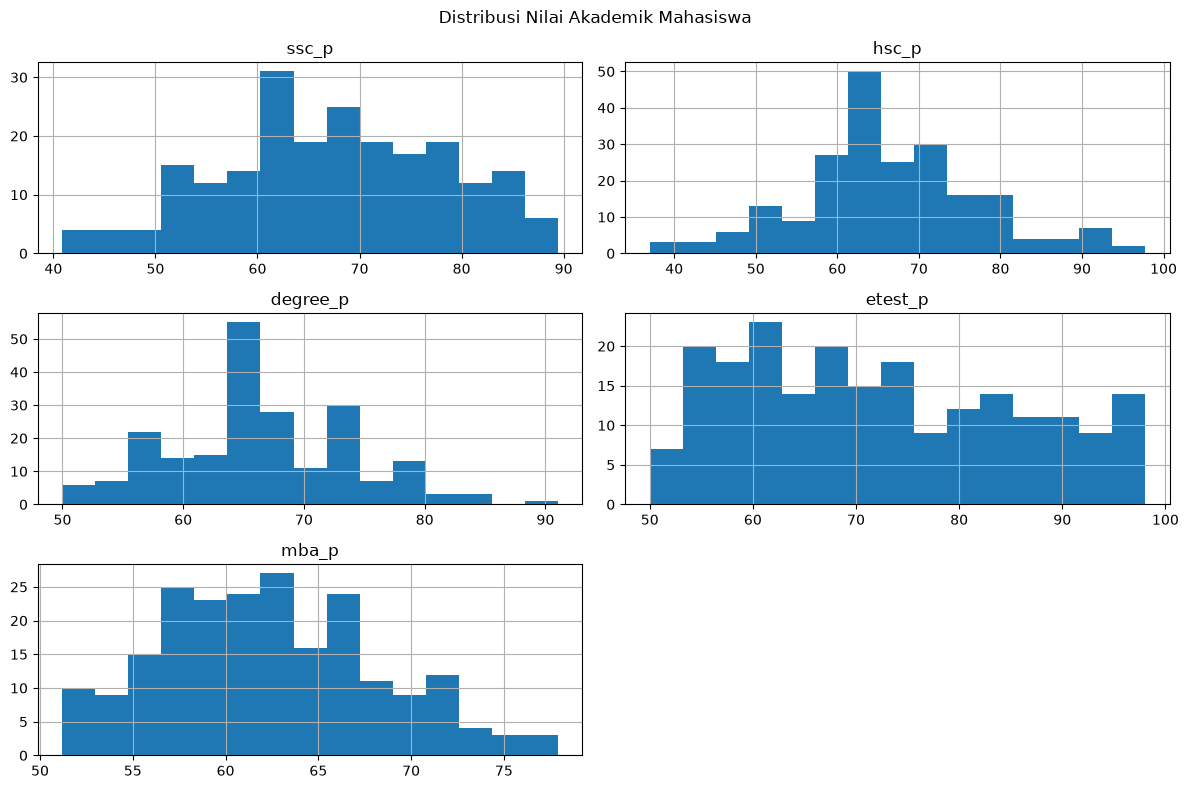

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

kolom_nilai = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p"
]

dataFrame[
    kolom_nilai
].hist(
    figsize=(12, 8),
    bins=15
)

plt.suptitle("Distribusi Nilai Akademik Mahasiswa")
plt.tight_layout()
plt.show()

### 6.2 Bar Chart - Jumlah Mahasiswa Berdasarkan Status Penempatan Kerja

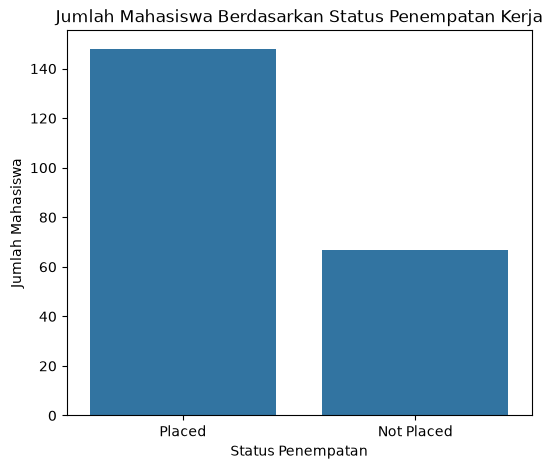

In [11]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=dataFrame,
    x="status"
)

plt.title("Jumlah Mahasiswa Berdasarkan Status Penempatan Kerja")
plt.xlabel("Status Penempatan")
plt.ylabel("Jumlah Mahasiswa")
plt.show()

### 6.3 Boxplot - Nilai MBA Berdasarkan Status Penempatan

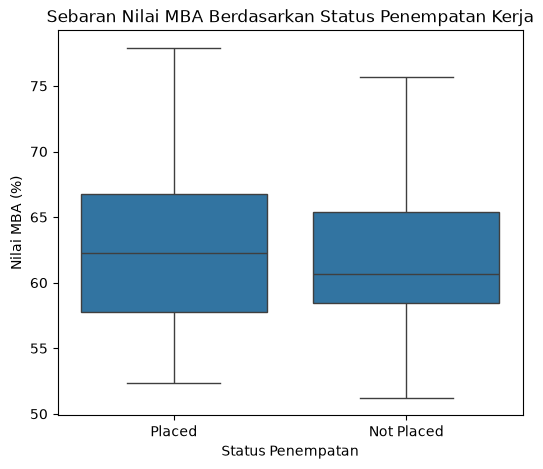

In [12]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=dataFrame,
    x="status",
    y="mba_p"
)

plt.title("Sebaran Nilai MBA Berdasarkan Status Penempatan Kerja")
plt.xlabel("Status Penempatan")
plt.ylabel("Nilai MBA (%)")
plt.show()

## 7. Korelasi Antar Atribut Numerik (Heatmap)

In [13]:
matriks_korelasi = dataFrame[
    atribut_numerik
].corr()

matriks_korelasi

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.063764
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.035330
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.076819
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,-0.019272
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.178307
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.175013
salary,0.063764,0.035330,0.076819,-0.019272,0.178307,0.175013,1.000000


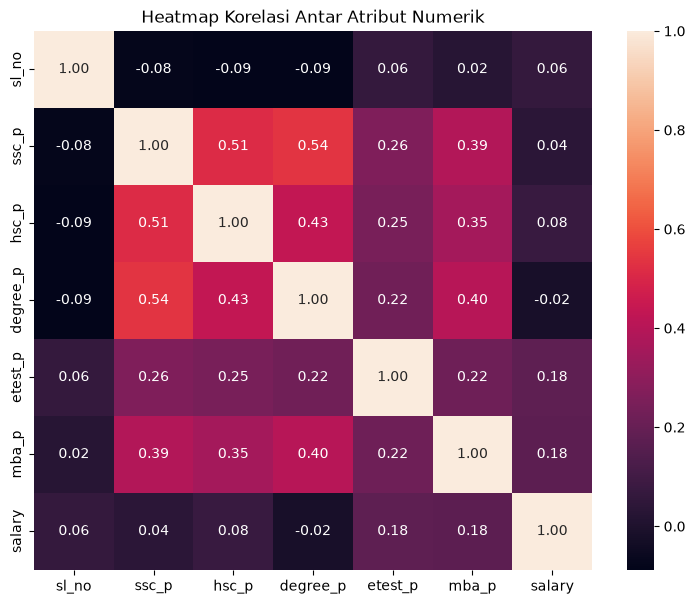

In [14]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    matriks_korelasi,
    annot=True,
    fmt=".2f"
)

plt.title("Heatmap Korelasi Antar Atribut Numerik")
plt.show()

Dari heatmap dapat dilihat pola korelasi antar nilai akademik mahasiswa, misalnya hubungan antara nilai SMP (`ssc_p`), SMA (`hsc_p`), nilai kuliah (`degree_p`), nilai tes kerja (`etest_p`), dan nilai MBA (`mba_p`).

## 8. Kesimpulan Sementara

Berdasarkan eksplorasi data di atas, dapat disimpulkan sementara bahwa:

1. Dataset terdiri dari 215 record dan 15 atribut, dengan atribut numerik dan kategorikal.
2. Status penempatan kerja terdiri dari `Placed` dan `Not Placed`.
3. Atribut nilai akademik dapat dilihat distribusinya menggunakan histogram.
4. Grafik batang dapat digunakan untuk membandingkan jumlah mahasiswa berdasarkan status penempatan kerja.
5. Boxplot dapat digunakan untuk melihat persebaran nilai MBA berdasarkan status penempatan.
6. Heatmap digunakan untuk melihat hubungan antar atribut numerik.

## 9. Data Preprocessing

Tahapan preprocessing meliputi pengecekan missing value, data duplikat, pemeriksaan outlier, normalisasi, encoding, dan feature engineering. Untuk proses klasifikasi, data numerik akan distandardisasi setelah pembagian training dan testing agar tidak terjadi kebocoran data.

### 9.1 Mengecek Missing Value

In [15]:
# Mengecek jumlah missing value pada setiap kolom
dataFrame.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

Pada dataset ini, kolom `salary` memiliki nilai kosong karena informasi gaji hanya tersedia untuk mahasiswa yang berstatus `Placed`. Kolom `salary` tidak digunakan sebagai fitur karena informasi tersebut berkaitan dengan hasil placement.

### 9.2 Mengecek Data Duplikat

In [16]:
# Mengecek jumlah data duplikat
print("Jumlah data duplikat sebelum dihapus:", dataFrame.duplicated().sum())

# Menghapus data duplikat jika ditemukan
dataFrame = dataFrame.drop_duplicates()

# Mengecek kembali jumlah data duplikat
print("Jumlah data duplikat setelah dihapus:", dataFrame.duplicated().sum())

Jumlah data duplikat sebelum dihapus: 0
Jumlah data duplikat setelah dihapus: 0


### 9.3 Handling Outlier

Outlier diperiksa menggunakan metode IQR (Interquartile Range). Nilai yang masih berada dalam batas IQR dipertahankan.

In [17]:
kolom_outlier = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p"
]

for kolom in kolom_outlier:
    Q1 = dataFrame[kolom].quantile(0.25)
    Q3 = dataFrame[kolom].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - (1.5 * IQR)
    batas_atas = Q3 + (1.5 * IQR)

    jumlah_outlier = (
        (dataFrame[kolom] < batas_bawah) |
        (dataFrame[kolom] > batas_atas)
    ).sum()

    print(kolom, ":", jumlah_outlier, "outlier")

ssc_p : 0 outlier
hsc_p : 8 outlier
degree_p : 1 outlier
etest_p : 0 outlier
mba_p : 0 outlier


## 10. Normalisasi Data Numerik

Normalisasi dilakukan menggunakan metode Min-Max Scaling agar nilai atribut numerik berada pada rentang 0 sampai 1.

In [18]:
kolom_normalisasi = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p"
]

for kolom in kolom_normalisasi:
    nilai_min = dataFrame[kolom].min()
    nilai_max = dataFrame[kolom].max()

    dataFrame[kolom] = (
        (dataFrame[kolom] - nilai_min) /
        (nilai_max - nilai_min)
    )

dataFrame[kolom_normalisasi].head()

,ssc_p,hsc_p,degree_p,etest_p,mba_p
0,0.538240,0.889621,0.195122,0.104167,0.284483
1,0.792414,0.680890,0.670244,0.760417,0.564843
2,0.497011,0.510708,0.341463,0.520833,0.247001
3,0.311482,0.247117,0.048780,0.333333,0.308096
4,0.925788,0.602965,0.568293,0.975000,0.160795


## 11. Encoding Kolom Kategorikal

One-Hot Encoding digunakan pada kolom kategorikal yang tidak memiliki urutan alami. Kolom `status` tidak diubah karena digunakan sebagai target label.

In [19]:
atribut_kategorikal = dataFrame.select_dtypes(
    include="object"
).columns.tolist()

atribut_kategorikal

/var/folders/3w/15hcpsv56lxff6t0n9z8q34w0000gn/T/ipykernel_32968/1304364895.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  atribut_kategorikal = dataFrame.select_dtypes(


['gender',
 'ssc_b',
 'hsc_b',
 'hsc_s',
 'degree_t',
 'workex',
 'specialisation',
 'status']

In [20]:
dataFrame = pd.get_dummies(
    dataFrame,
    columns=[
        "gender",
        "ssc_b",
        "hsc_b",
        "hsc_s",
        "degree_t",
        "workex",
        "specialisation"
    ]
)

dataFrame.head()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,status,salary,gender_F,gender_M,...,hsc_s_Arts,hsc_s_Commerce,hsc_s_Science,degree_t_Comm&Mgmt,degree_t_Others,degree_t_Sci&Tech,workex_No,workex_Yes,specialisation_Mkt&Fin,specialisation_Mkt&HR
0,1,0.538240,0.889621,0.195122,0.104167,0.284483,Placed,270000.0,False,True,...,False,True,False,False,False,True,True,False,False,True
1,2,0.792414,0.680890,0.670244,0.760417,0.564843,Placed,200000.0,False,True,...,False,False,True,False,False,True,False,True,True,False
2,3,0.497011,0.510708,0.341463,0.520833,0.247001,Placed,250000.0,False,True,...,True,False,False,True,False,False,True,False,True,False
3,4,0.311482,0.247117,0.048780,0.333333,0.308096,Not Placed,NaN,False,True,...,False,False,True,False,False,True,True,False,False,True
4,5,0.925788,0.602965,0.568293,0.975000,0.160795,Placed,425000.0,False,True,...,False,True,False,True,False,False,True,False,True,False


## 12. Feature Engineering

Fitur baru yang dibuat adalah `academic_average`, yaitu rata-rata nilai asli `ssc_p`, `hsc_p`, dan `degree_p`. Fitur ini tidak menggunakan target `status`.

In [21]:
dataFrame_raw["academic_average"] = (
    dataFrame_raw["ssc_p"] +
    dataFrame_raw["hsc_p"] +
    dataFrame_raw["degree_p"]
) / 3

dataFrame_raw[["ssc_p", "hsc_p", "degree_p", "academic_average"]].head()

,ssc_p,hsc_p,degree_p,academic_average
0,67.00,91.00,58.00,72.000000
1,79.33,78.33,77.48,78.380000
2,65.00,68.00,64.00,65.666667
3,56.00,52.00,52.00,53.333333
4,85.80,73.60,73.30,77.566667


## 13. Hasil Akhir Data Preprocessing

In [22]:
print("Jumlah baris :", dataFrame.shape[0])
print("Jumlah kolom :", dataFrame.shape[1])

dataFrame.head()

Jumlah baris : 215
Jumlah kolom : 24


,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,status,salary,gender_F,gender_M,...,hsc_s_Arts,hsc_s_Commerce,hsc_s_Science,degree_t_Comm&Mgmt,degree_t_Others,degree_t_Sci&Tech,workex_No,workex_Yes,specialisation_Mkt&Fin,specialisation_Mkt&HR
0,1,0.538240,0.889621,0.195122,0.104167,0.284483,Placed,270000.0,False,True,...,False,True,False,False,False,True,True,False,False,True
1,2,0.792414,0.680890,0.670244,0.760417,0.564843,Placed,200000.0,False,True,...,False,False,True,False,False,True,False,True,True,False
2,3,0.497011,0.510708,0.341463,0.520833,0.247001,Placed,250000.0,False,True,...,True,False,False,True,False,False,True,False,True,False
3,4,0.311482,0.247117,0.048780,0.333333,0.308096,Not Placed,NaN,False,True,...,False,False,True,False,False,True,True,False,False,True
4,5,0.925788,0.602965,0.568293,0.975000,0.160795,Placed,425000.0,False,True,...,False,True,False,True,False,False,True,False,True,False


In [23]:
dataFrame.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sl_no                   215 non-null    int64  
 1   ssc_p                   215 non-null    float64
 2   hsc_p                   215 non-null    float64
 3   degree_p                215 non-null    float64
 4   etest_p                 215 non-null    float64
 5   mba_p                   215 non-null    float64
 6   status                  215 non-null    str    
 7   salary                  148 non-null    float64
 8   gender_F                215 non-null    bool   
 9   gender_M                215 non-null    bool   
 10  ssc_b_Central           215 non-null    bool   
 11  ssc_b_Others            215 non-null    bool   
 12  hsc_b_Central           215 non-null    bool   
 13  hsc_b_Others            215 non-null    bool   
 14  hsc_s_Arts              215 non-null    bool   
 15  

### Kesimpulan

Pada tahap preprocessing, dataset telah diperiksa dari missing value, data duplikat, dan outlier. Atribut numerik juga dinormalisasi dan atribut kategorikal diubah menggunakan One-Hot Encoding sebagai bagian dari proses preprocessing. Untuk klasifikasi, digunakan data numerik asli yang kemudian distandardisasi setelah train-test split agar informasi dari data testing tidak ikut memengaruhi proses pelatihan. Fitur `academic_average` dibuat dari nilai asli SSC, HSC, dan Degree.

## 14. Persiapan Data untuk Klasifikasi

Target yang digunakan adalah `status`, sedangkan fitur yang digunakan adalah nilai akademik dan hasil tes kerja. Kolom `salary` tidak digunakan karena berhubungan dengan hasil placement.

In [24]:
# Menggunakan salinan data asli agar fitur klasifikasi tidak dipengaruhi normalisasi EDA
data_klasifikasi = dataFrame_raw.drop_duplicates().copy()

data_klasifikasi["academic_average"] = (
    data_klasifikasi["ssc_p"] +
    data_klasifikasi["hsc_p"] +
    data_klasifikasi["degree_p"]
) / 3

fitur = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p",
    "academic_average"
]

target = "status"

data_klasifikasi = data_klasifikasi[fitur + [target]].dropna()

X = data_klasifikasi[fitur]
y = data_klasifikasi[target]

print("Fitur yang digunakan:", fitur)
print("Jumlah data:", data_klasifikasi.shape)
print("Distribusi target:")
print(y.value_counts())

Fitur yang digunakan: ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'academic_average']
Jumlah data: (215, 7)
Distribusi target:
status
Placed        148
Not Placed     67
Name: count, dtype: int64


In [25]:
# Menginstal library yang diperlukan untuk machine learning
%pip install -q scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 15. Membagi Data Training dan Testing

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 172
Jumlah data testing: 43


## 16. Standardisasi Data

Standardisasi dilakukan setelah data dibagi menjadi training dan testing. `StandardScaler` hanya dipelajari dari data training, kemudian digunakan untuk mengubah data testing dengan skala yang sama.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardisasi data berhasil dilakukan.")

Standardisasi data berhasil dilakukan.


## 17. Membuat dan Melatih Model

Dua algoritma yang digunakan adalah Support Vector Machine (SVM) dan Gaussian Naive Bayes.

In [28]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

nb_model = GaussianNB()

svm_model.fit(X_train_scaled, y_train)
nb_model.fit(X_train_scaled, y_train)

print("Model SVM dan Naive Bayes berhasil dilatih.")

Model SVM dan Naive Bayes berhasil dilatih.


## 18. Melakukan Prediksi

In [29]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_nb = nb_model.predict(X_test_scaled)

print("Prediksi SVM:")
print(y_pred_svm)

print("\nPrediksi Naive Bayes:")
print(y_pred_nb)

Prediksi SVM:
['Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed'
 'Not Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed'
 'Placed' 'Placed' 'Placed' 'Placed' 'Not Placed' 'Not Placed'
 'Not Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed'
 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Not Placed' 'Not Placed'
 'Placed' 'Placed' 'Not Placed' 'Placed' 'Not Placed' 'Placed' 'Placed'
 'Not Placed']

Prediksi Naive Bayes:
['Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed'
 'Not Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed'
 'Placed' 'Placed' 'Placed' 'Placed' 'Not Placed' 'Not Placed'
 'Not Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed'
 'Placed' 'Placed' 'Placed' 'Placed' 'Not Placed' 'Not Placed' 'Placed'
 'Placed' 'Placed' 'Not Placed' 'Placed' 'Not Placed' 'Placed'
 'Not Placed' 'Not Placed']


## 19. Evaluasi Model

Evaluasi dilakukan menggunakan Accuracy, Precision, Recall, dan F1-Score.

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        pos_label="Placed",
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        pos_label="Placed",
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        pos_label="Placed",
        zero_division=0
    )

    print(f"===== {model_name} =====")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

result_svm = evaluate_model(
    "Support Vector Machine",
    y_test,
    y_pred_svm
)

result_nb = evaluate_model(
    "Naive Bayes",
    y_test,
    y_pred_nb
)

===== Support Vector Machine =====
Accuracy  : 0.8140
Precision : 0.8235
Recall    : 0.9333
F1-Score  : 0.8750

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.78      0.54      0.64        13
      Placed       0.82      0.93      0.88        30

    accuracy                           0.81        43
   macro avg       0.80      0.74      0.76        43
weighted avg       0.81      0.81      0.80        43

===== Naive Bayes =====
Accuracy  : 0.8372
Precision : 0.8485
Recall    : 0.9333
F1-Score  : 0.8889

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.80      0.62      0.70        13
      Placed       0.85      0.93      0.89        30

    accuracy                           0.84        43
   macro avg       0.82      0.77      0.79        43
weighted avg       0.83      0.84      0.83        43



## 20. Perbandingan Hasil Evaluasi

In [31]:
results = pd.DataFrame([
    result_svm,
    result_nb
])

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Support Vector Machine,0.813953,0.823529,0.933333,0.875000
1,Naive Bayes,0.837209,0.848485,0.933333,0.888889


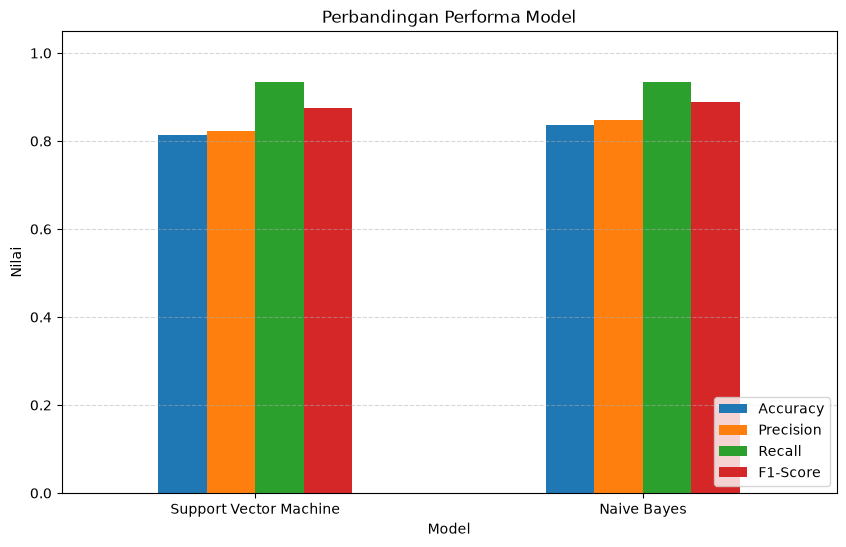

In [32]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Perbandingan Performa Model")
plt.xlabel("Model")
plt.ylabel("Nilai")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Interpretasi Hasil Evaluasi

Accuracy menunjukkan proporsi seluruh prediksi yang benar. Precision menunjukkan ketepatan model ketika memprediksi mahasiswa berstatus `Placed`, sedangkan Recall menunjukkan kemampuan model menemukan data yang sebenarnya `Placed`. F1-Score digunakan untuk melihat keseimbangan antara Precision dan Recall. Perbedaan hasil kedua model dapat terjadi karena SVM dan Naive Bayes memiliki cara yang berbeda dalam mempelajari pola data.

## 21. Confusion Matrix

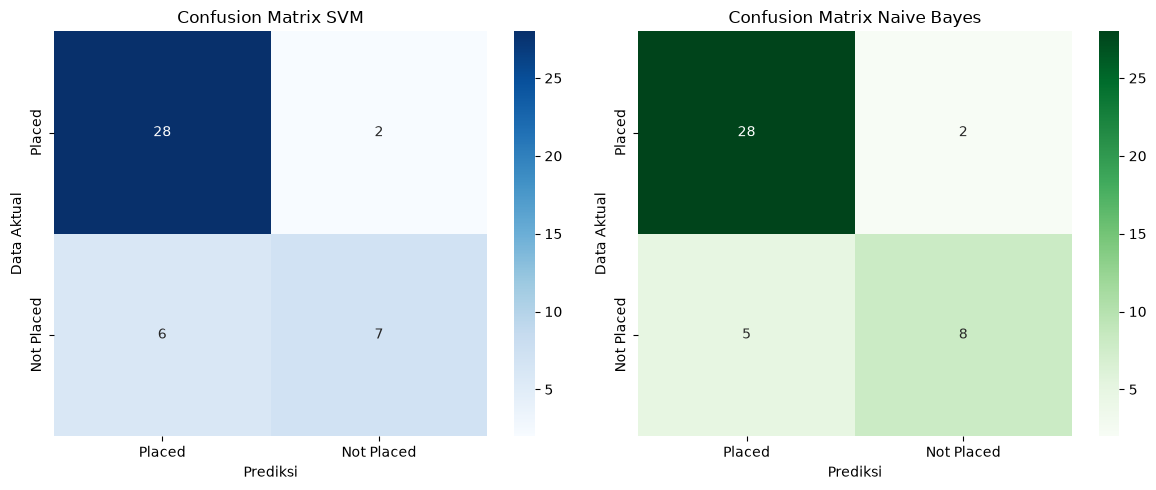

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["Placed", "Not Placed"]
)

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["Placed", "Not Placed"]
)

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Placed", "Not Placed"],
    yticklabels=["Placed", "Not Placed"],
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix SVM")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Data Aktual")

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Placed", "Not Placed"],
    yticklabels=["Placed", "Not Placed"],
    ax=axes[1]
)

axes[1].set_title("Confusion Matrix Naive Bayes")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Data Aktual")

plt.tight_layout()
plt.show()

## 22. Perbandingan Prediksi

In [34]:
prediction_comparison = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi SVM": y_pred_svm,
    "Prediksi Naive Bayes": y_pred_nb
})

prediction_comparison.head(20)

,Aktual,Prediksi SVM,Prediksi Naive Bayes
0,Not Placed,Placed,Placed
1,Placed,Placed,Placed
2,Placed,Placed,Placed
3,Not Placed,Placed,Placed
4,Placed,Placed,Placed
5,Not Placed,Placed,Placed
6,Placed,Placed,Placed
7,Placed,Placed,Placed
8,Not Placed,Not Placed,Not Placed
9,Placed,Placed,Placed


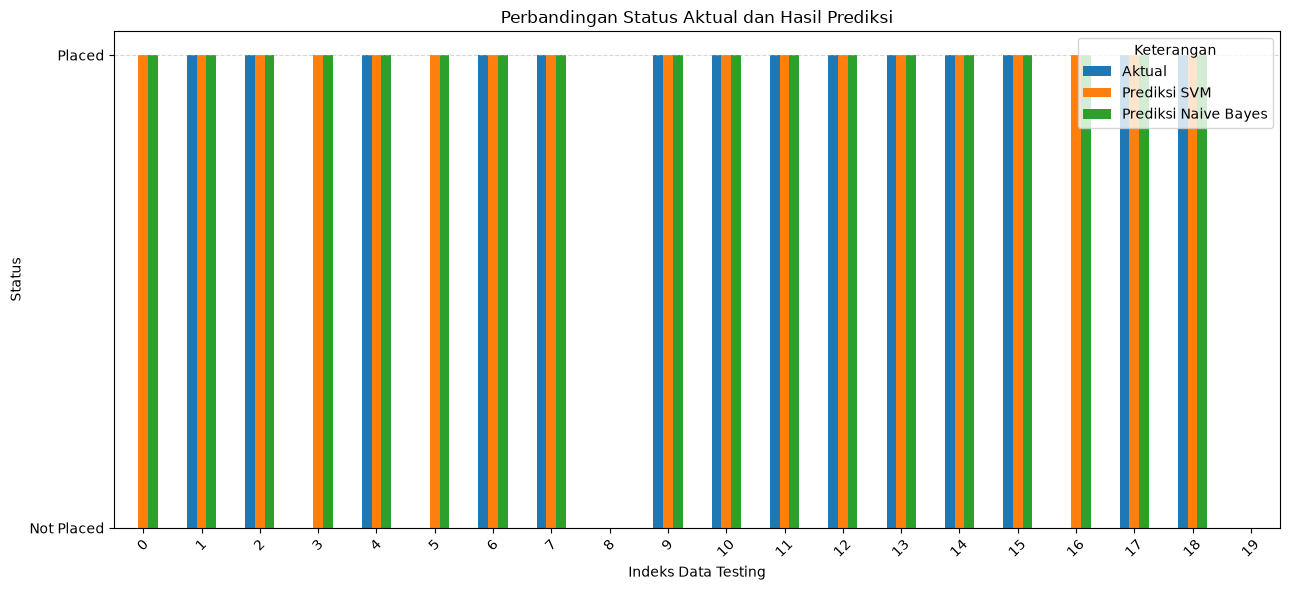

In [35]:
status_mapping = {
    "Not Placed": 0,
    "Placed": 1
}

prediction_numeric = prediction_comparison.replace(status_mapping)

prediction_numeric.head(20).plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Perbandingan Status Aktual dan Hasil Prediksi")
plt.xlabel("Indeks Data Testing")
plt.ylabel("Status")
plt.yticks([0, 1], ["Not Placed", "Placed"])
plt.xticks(rotation=45)
plt.legend(title="Keterangan")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 23. Kesimpulan Akhir

Dataset Campus Student Placement telah melalui tahap eksplorasi data, data cleaning, pemeriksaan outlier, preprocessing, dan feature engineering. Fitur `academic_average` dibuat dari rata-rata nilai SSC, HSC, dan Degree.

Untuk klasifikasi status penempatan kerja, digunakan enam variabel input yaitu `ssc_p`, `hsc_p`, `degree_p`, `etest_p`, `mba_p`, dan `academic_average`. Data dibagi menjadi training dan testing, kemudian distandardisasi setelah pembagian data.

Dua model yang digunakan adalah Support Vector Machine dan Gaussian Naive Bayes. Keduanya dievaluasi menggunakan Accuracy, Precision, Recall, F1-Score, classification report, confusion matrix, dan grafik perbandingan prediksi. Hasil evaluasi tersebut menunjukkan bagaimana masing-masing model bekerja pada data testing dalam membedakan mahasiswa yang berstatus `Placed` dan `Not Placed`.